<a href="https://colab.research.google.com/github/Raoina/Spectra-2-Image/blob/main/notebooks/Image_Transformation/%2002_GAF_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path = '/content/drive/MyDrive/LUCAS.SOIL_corr.csv'

In [3]:
import pandas as pd

df = pd.read_csv(file_path)

df.head()

/tmp/ipython-input-3672932280.py:3: DtypeWarning: Columns (1,2,4216,4231,4234,4237,4274) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Unnamed: 0,sample.ID,ID,date,spc.400,spc.400.5,spc.401,spc.401.5,spc.402,spc.402.5,...,WRBLV1,WRBADJ1,PARMADO1,PARMADO2,PARMADO3,PARMASE1,PARMASE2,PARMASE3,MIN_TOP,mineral
0,4,100,100,2011-01-24 16:02:25,0.831705,0.839111,0.846473,0.853773,0.860988,0.868098,...,CM,dy,3.0,31.0,310.0,5.0,56.0,561.0,KQ,mineral
1,5,1000,1000,2010-09-30 14:50:01,0.706027,0.714901,0.723727,0.732480,0.741142,0.749684,...,CM,dy,3.0,31.0,311.0,3.0,31.0,310.0,KQ,mineral
2,6,10000,10000,2010-10-19 12:06:16,0.666238,0.676472,0.686654,0.696757,0.706753,0.716615,...,CM,ca,2.0,21.0,214.0,0.0,0.0,0.0,MS,mineral
3,7,10001,10001,2010-10-19 15:00:01,0.698136,0.706548,0.714909,0.723197,0.731384,0.739448,...,CM,dy,3.0,31.0,310.0,4.0,42.0,420.0,KQ,mineral
4,8,10002,10002,2011-04-30 12:26:27,0.675433,0.684820,0.694163,0.703438,0.712620,0.721693,...,LV,ha,7.0,71.0,710.0,6.0,62.0,620.0,M,mineral


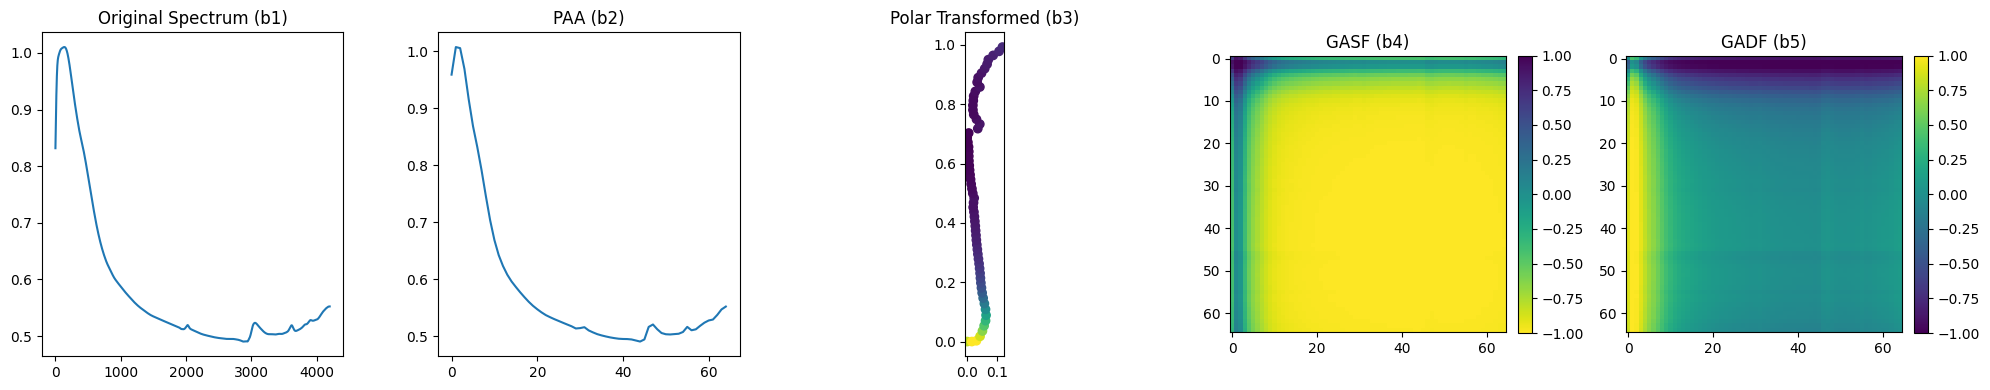

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. Select the first sample ----------
row = df.iloc[0]
spectrum = row.filter(like="spc.")
intensity = spectrum.values.astype(float)

# ---------- 2. Piecewise Aggregate Approximation (PAA) ----------
def paa(series, segments):
    n = len(series)
    if n % segments != 0:
        pad_size = segments - (n % segments)
        series = np.append(series, [series[-1]] * pad_size)  # Pad with last value
    k = len(series) // segments
    return np.array([series[i*k:(i+1)*k].mean() for i in range(segments)])

segments = 65
paa_series = paa(intensity, segments)  # This is qi in equation (1)

# ---------- 3. Normalize to [0,1] AFTER PAA ----------
min_val, max_val = paa_series.min(), paa_series.max()
normalized_paa = (paa_series - min_val) / (max_val - min_val)  # ̃qi in equation (2)

# ---------- 4. Polar coordinate transformation ----------
phi = np.arccos(normalized_paa)             # Angle φi = arccos(̃qi), from equation (3)
r = np.linspace(0, 1, len(normalized_paa))  # Radius r = i/n

# ---------- 5. Compute GASF and GADF ----------
phi_matrix = np.outer(phi, np.ones_like(phi))      # Matrix of angles
GASF = np.cos(phi_matrix + phi_matrix.T)           # Equation (4)
GADF = np.sin(phi_matrix - phi_matrix.T)           # Equation (5)

# ---------- 6. Visualization ----------
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

# (b1) Original spectrum
axs[0].plot(intensity)
axs[0].set_title("Original Spectrum (b1)")

# (b2) PAA-reduced series
axs[1].plot(paa_series)
axs[1].set_title("PAA (b2)")

# (b3) Polar transformed (circular plot)
axs[2].scatter(r * np.cos(phi), r * np.sin(phi), c=normalized_paa, cmap="viridis")
axs[2].set_title("Polar Transformed (b3)")
axs[2].set_aspect('equal')  # Ensures the plot is circular

# (b4) GASF matrix
im1 = axs[3].imshow(GASF, cmap="viridis_r", origin="upper", vmin=-1, vmax=1)
axs[3].set_title("GASF (b4)")
plt.colorbar(im1, ax=axs[3], fraction=0.046, pad=0.04)

# (b5) GADF matrix
im2 = axs[4].imshow(GADF, cmap="viridis", origin="upper", vmin=-1, vmax=1)
axs[4].set_title("GADF (b5)")
plt.colorbar(im2, ax=axs[4], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

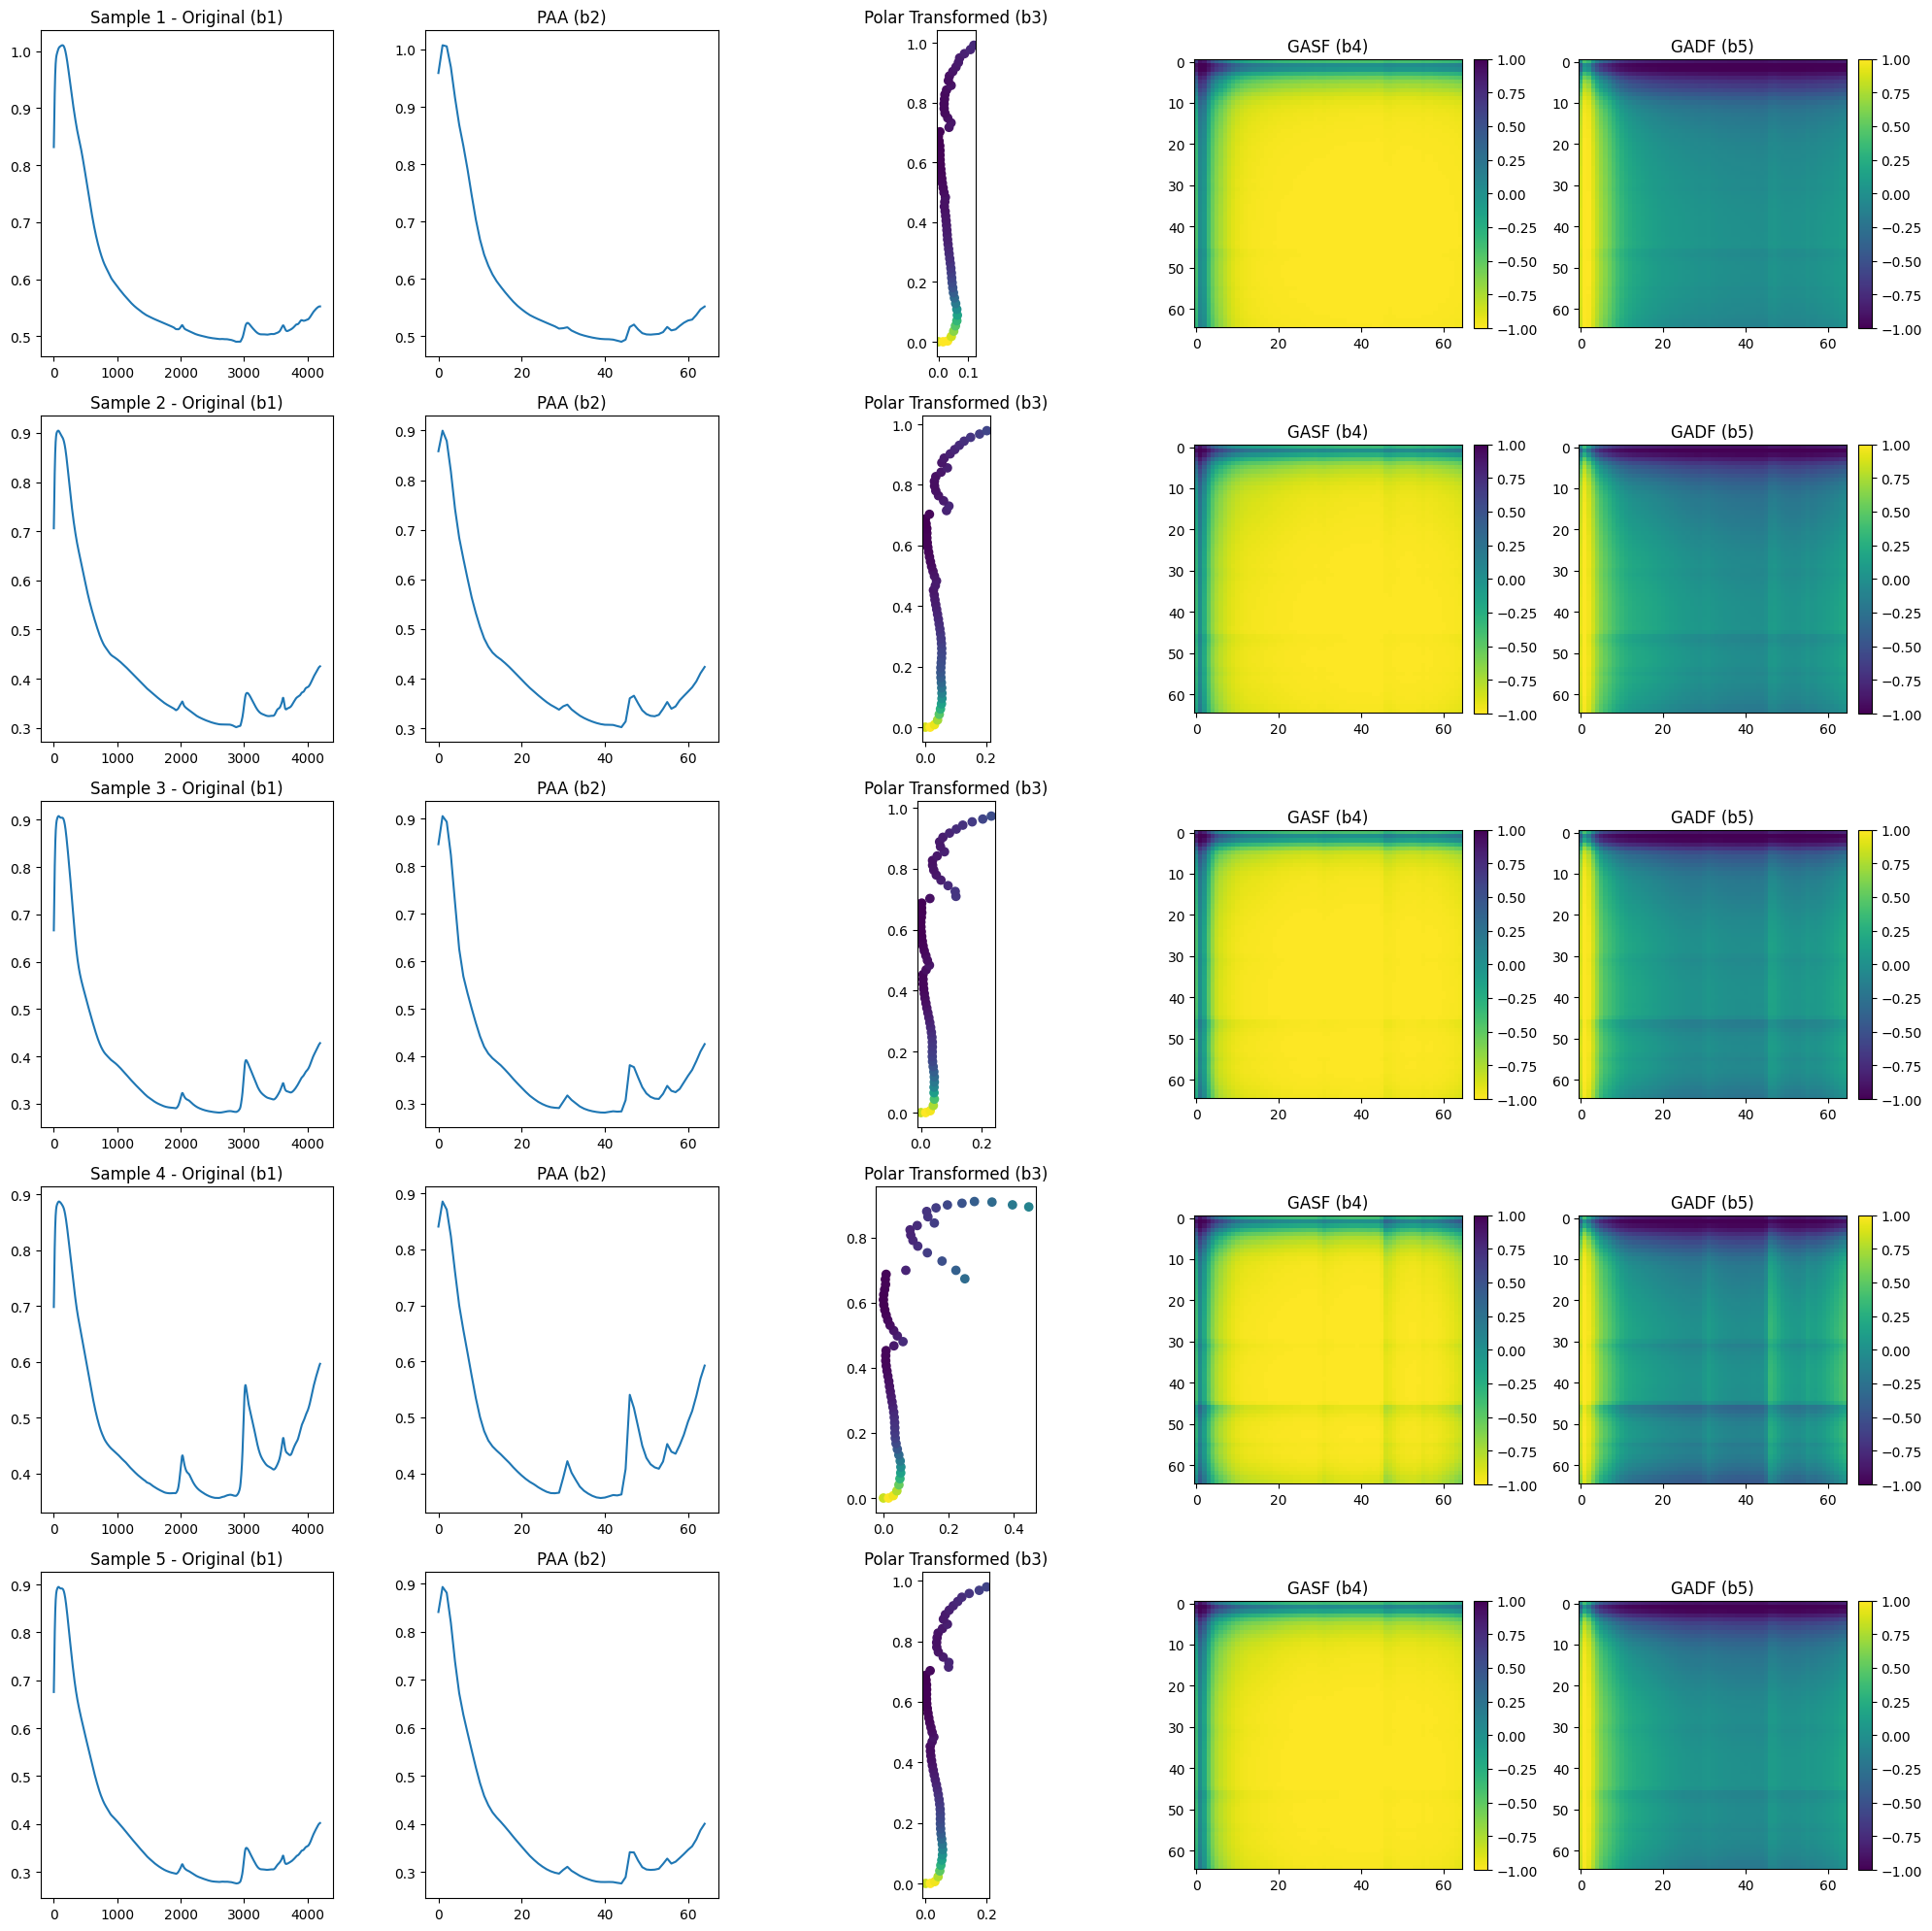

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Function: PAA ----------
def paa(series, segments):
    n = len(series)
    if n % segments != 0:
        pad_size = segments - (n % segments)
        series = np.append(series, [series[-1]] * pad_size)
    k = len(series) // segments
    return np.array([series[i*k:(i+1)*k].mean() for i in range(segments)])

# ---------- Parameters ----------
segments = 65
num_samples = 5

# ---------- Plotting ----------
fig, axs = plt.subplots(num_samples, 5, figsize=(20, 4 * num_samples))

for i in range(num_samples):
    # 1. Get spectrum
    row = df.iloc[i]
    spectrum = row.filter(like="spc.")
    intensity = spectrum.values.astype(float)

    # 2. PAA
    paa_series = paa(intensity, segments)

    # 3. Normalize AFTER PAA
    min_val, max_val = paa_series.min(), paa_series.max()
    normalized_paa = (paa_series - min_val) / (max_val - min_val)

    # 4. Polar transform
    phi = np.arccos(normalized_paa)
    r = np.linspace(0, 1, len(normalized_paa))

    # 5. GASF & GADF
    phi_matrix = np.outer(phi, np.ones_like(phi))
    GASF = np.cos(phi_matrix + phi_matrix.T)
    GADF = np.sin(phi_matrix - phi_matrix.T)

    # 6. Plot results
    axs[i, 0].plot(intensity)
    axs[i, 0].set_title(f"Sample {i+1} - Original (b1)")

    axs[i, 1].plot(paa_series)
    axs[i, 1].set_title("PAA (b2)")

    axs[i, 2].scatter(r * np.cos(phi), r * np.sin(phi), c=normalized_paa, cmap="viridis")
    axs[i, 2].set_title("Polar Transformed (b3)")
    axs[i, 2].set_aspect('equal')

    im1 = axs[i, 3].imshow(GASF, cmap="viridis_r", origin="upper", vmin=-1, vmax=1)
    axs[i, 3].set_title("GASF (b4)")
    fig.colorbar(im1, ax=axs[i, 3], fraction=0.046, pad=0.04)

    im2 = axs[i, 4].imshow(GADF, cmap="viridis", origin="upper", vmin=-1, vmax=1)
    axs[i, 4].set_title("GADF (b5)")
    fig.colorbar(im2, ax=axs[i, 4], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [6]:
!pip install pyts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.4 MB/s eta 0:00:00


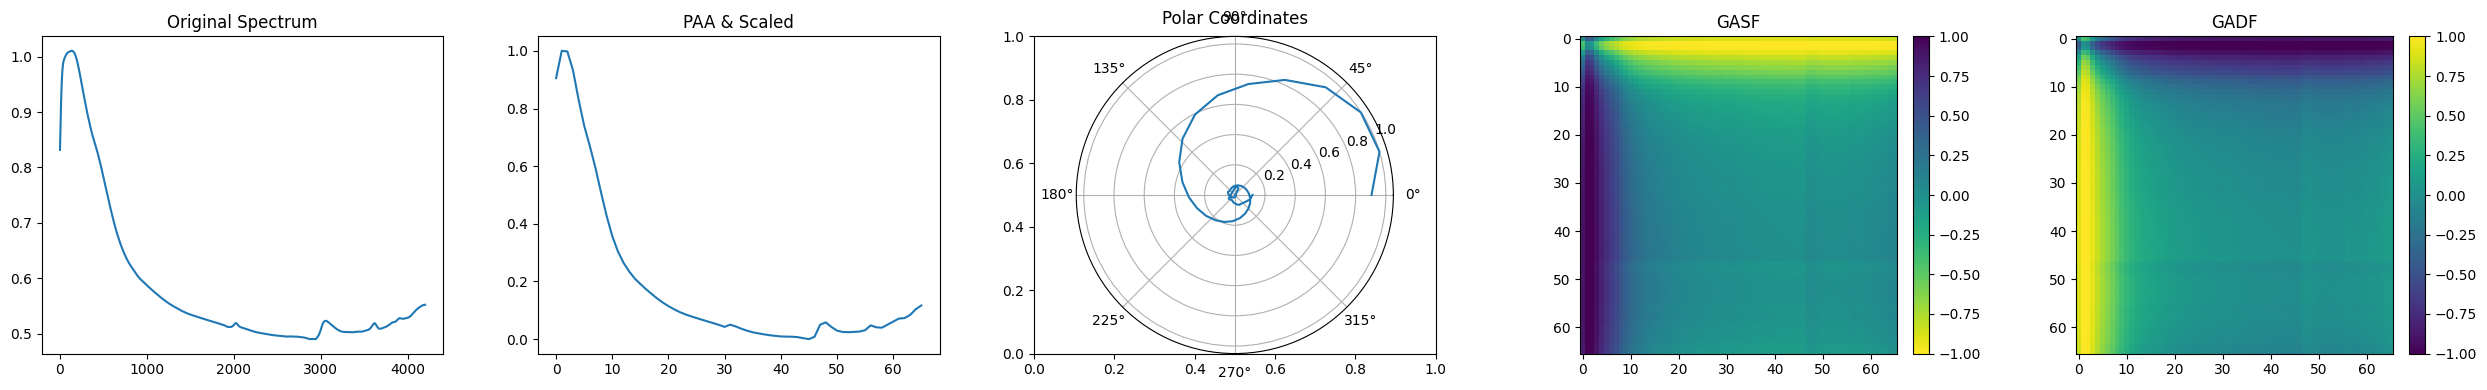

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyts.approximation import PiecewiseAggregateApproximation
from pyts.preprocessing import MinMaxScaler

# ---------------- 0. Load data ----------------
# Make sure your DataFrame `df` is loaded and contains columns starting with "spc."
# Example: df = pd.read_csv("your_spectrum.csv")

# ---------- 1. Select one sample ----------
row = df.iloc[0]  # Select the first sample (change index if needed)
spectrum = row.filter(like="spc.")  # Select only spectral columns
intensity = spectrum.values.astype(float)  # Convert to float array

# Adjust number of segments
segments = 65  # Or even len(intensity)

# Safe PAA window size
window_size = max(1, int(len(intensity) / segments))
paa = PiecewiseAggregateApproximation(window_size=window_size)
paa_series = paa.fit_transform(intensity.reshape(1, -1)).flatten()

# Scaling
scaler = MinMaxScaler()
scaled_paa = scaler.fit_transform(paa_series.reshape(1, -1)).flatten()

# Polar plot with more spiral loops
theta = np.linspace(0, 6 * np.pi, len(scaled_paa))  # You can increase this further
r = scaled_paa

# ---------- 5. Gramian Angular Fields ----------
phi = np.arccos(scaled_paa)
phi_matrix = np.outer(phi, np.ones_like(phi))
GASF = np.cos(phi_matrix + phi_matrix.T)
GADF = np.sin(phi_matrix - phi_matrix.T)

# ---------- 6. Visualization ----------
fig, axs = plt.subplots(1, 5, figsize=(25, 4))

# (a) Original Spectrum
axs[0].plot(intensity)
axs[0].set_title("Original Spectrum")

# (b) PAA & Scaled
axs[1].plot(scaled_paa)
axs[1].set_title("PAA & Scaled")

# (c) Polar Coordinates (Spiral Style)
ax = fig.add_subplot(1, 5, 3, projection='polar')
ax.plot(theta, r)
ax.set_title("Polar Coordinates", va='bottom')
ax.grid(True)

# (d) GASF
im1 = axs[3].imshow(GADF, cmap="viridis_r", origin="upper", vmin=-1, vmax=1)
axs[3].set_title("GASF")
plt.colorbar(im1, ax=axs[3], fraction=0.046, pad=0.04)

# (e) GADF
im2 = axs[4].imshow(GADF, cmap="viridis", origin="upper", vmin=-1, vmax=1)
axs[4].set_title("GADF")
plt.colorbar(im2, ax=axs[4], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------- Function: PAA ----------
def paa(series, segments):
    n = len(series)
    if n % segments != 0:
        pad_size = segments - (n % segments)
        series = np.append(series, [series[-1]] * pad_size)
    k = len(series) // segments
    return np.array([series[i*k:(i+1)*k].mean() for i in range(segments)])

# ---------- Parameters ----------
segments = 65
batch_size = 1000
num_samples = len(df)

# ---------- Output dirs ----------
os.makedirs("GASF_images", exist_ok=True)
os.makedirs("GADF_images", exist_ok=True)

for batch_start in range(0, num_samples, batch_size):
    batch_end = min(batch_start + batch_size, num_samples)

    for idx in range(batch_start, batch_end):
        # 1. Get spectrum
        row = df.iloc[idx]
        spectrum = row.filter(like="spc.")
        intensity = spectrum.values.astype(float)

        # 2. PAA
        paa_series = paa(intensity, segments)

        # 3. Normalize AFTER PAA
        min_val, max_val = paa_series.min(), paa_series.max()
        normalized_paa = (paa_series - min_val) / (max_val - min_val)

        # 4. Polar transform
        phi = np.arccos(normalized_paa)

        # 5. GASF & GADF
        phi_matrix = np.outer(phi, np.ones_like(phi))
        GASF = np.cos(phi_matrix + phi_matrix.T)
        GADF = np.sin(phi_matrix - phi_matrix.T)

        # ---------- Save GASF ----------
        plt.figure(figsize=(3, 3))
        plt.imshow(GASF, cmap="viridis_r", origin="upper", vmin=-1, vmax=1)
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join("GASF_images", f"NIR_{idx}.png"), dpi=100)
        plt.close()

        # ---------- Save GADF ----------
        plt.figure(figsize=(3, 3))
        plt.imshow(GADF, cmap="viridis", origin="upper", vmin=-1, vmax=1)
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join("GADF_images", f"NIR_{idx}.png"), dpi=100)
        plt.close()

    print(f"Batch {batch_start} to {batch_end-1} done ✅")


Batch 0 to 999 done ✅
Batch 1000 to 1999 done ✅
Batch 2000 to 2999 done ✅
Batch 3000 to 3999 done ✅
Batch 4000 to 4999 done ✅
Batch 5000 to 5999 done ✅


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------- Function: PAA ----------
def paa(series, segments):
    n = len(series)
    if n % segments != 0:
        pad_size = segments - (n % segments)
        series = np.append(series, [series[-1]] * pad_size)
    k = len(series) // segments
    return np.array([series[i*k:(i+1)*k].mean() for i in range(segments)])

# ---------- Parameters ----------
segments = 65
batch_size = 1000
num_samples = len(df)

# ---------- Output dirs ----------
os.makedirs("GASF_images", exist_ok=True)
os.makedirs("GADF_images", exist_ok=True)

for batch_start in range(6000, num_samples, batch_size):
    batch_end = min(batch_start + batch_size, num_samples)

    for idx in range(batch_start, batch_end):
        # 1. Get spectrum
        row = df.iloc[idx]
        spectrum = row.filter(like="spc.")
        intensity = spectrum.values.astype(float)

        # 2. PAA
        paa_series = paa(intensity, segments)

        # 3. Normalize AFTER PAA
        min_val, max_val = paa_series.min(), paa_series.max()
        normalized_paa = (paa_series - min_val) / (max_val - min_val)

        # 4. Polar transform
        phi = np.arccos(normalized_paa)

        # 5. GASF & GADF
        phi_matrix = np.outer(phi, np.ones_like(phi))
        GASF = np.cos(phi_matrix + phi_matrix.T)
        GADF = np.sin(phi_matrix - phi_matrix.T)

        # ---------- Save GASF ----------
        plt.figure(figsize=(3, 3))
        plt.imshow(GASF, cmap="viridis_r", origin="upper", vmin=-1, vmax=1)
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join("GASF_images", f"NIR_{idx}.png"), dpi=100)
        plt.close()

        # ---------- Save GADF ----------
        plt.figure(figsize=(3, 3))
        plt.imshow(GADF, cmap="viridis", origin="upper", vmin=-1, vmax=1)
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join("GADF_images", f"NIR_{idx}.png"), dpi=100)
        plt.close()

    print(f"Batch {batch_start} to {batch_end-1} done ✅")


NameError: name 'df' is not defined

In [2]:
import shutil
from google.colab import files

# ---------- Compress folders ----------
shutil.make_archive("GASF_images", 'zip', "GASF_images")
shutil.make_archive("GADF_images", 'zip', "GADF_images")

# ---------- Download ----------
files.download("GASF_images.zip")
files.download("GADF_images.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>